<a href="https://colab.research.google.com/github/ergul13/mr_akgul/blob/main/veri_m%C3%BChendisligi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri'

Mounted at /content/drive


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'

df_inbreast = pd.read_csv(path + 'INbreast.csv', sep=';')
df_inbreast = df_inbreast.rename(columns={'Bi-Rads': 'birads_unified'})
df_inbreast['birads_unified'] = pd.to_numeric(df_inbreast['birads_unified'], errors='coerce')

df_rsna = pd.read_csv(path + 'train.csv')
df_rsna = df_rsna.rename(columns={'BIRADS': 'birads_unified'})

df_vindr = pd.read_csv(path + 'vinDr.csv')
df_vindr['birads_unified'] = df_vindr['breast_birads'].str.extract(r'(\d+)').astype(float)

print("INbreast BI-RADS Dağılımı:")
print(df_inbreast['birads_unified'].value_counts(dropna=False))

print("\nRSNA BI-RADS Dağılımı:")
print(df_rsna['birads_unified'].value_counts(dropna=False))

print("\nVinDr BI-RADS Dağılımı:")
print(df_vindr['birads_unified'].value_counts(dropna=False))

INbreast BI-RADS Dağılımı:
birads_unified
2.0    220
1.0     67
5.0     49
NaN     43
3.0     23
6.0      8
Name: count, dtype: int64

RSNA BI-RADS Dağılımı:
birads_unified
NaN    28420
1.0    15772
0.0     8249
2.0     2265
Name: count, dtype: int64

VinDr BI-RADS Dağılımı:
birads_unified
1.0    13406
2.0     4676
3.0      930
4.0      762
5.0      226
Name: count, dtype: int64


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'

df_inbreast = pd.read_csv(path + 'INbreast.csv', sep=';')
df_inbreast = df_inbreast.rename(columns={'Bi-Rads': 'birads'})
df_inbreast['birads'] = df_inbreast['birads'].astype(str).str.replace(r'4[a-cA-C]', '4', regex=True)
df_inbreast['birads'] = pd.to_numeric(df_inbreast['birads'], errors='coerce')

df_rsna = pd.read_csv(path + 'train.csv')
df_rsna = df_rsna.rename(columns={'BIRADS': 'birads'})

df_vindr = pd.read_csv(path + 'vinDr.csv')
df_vindr['birads'] = df_vindr['breast_birads'].str.extract(r'(\d+)').astype(float)

hedef_siniflar = [1, 2, 4, 5]

df_inbreast_hedef = df_inbreast[df_inbreast['birads'].isin(hedef_siniflar)].copy()
df_rsna_hedef = df_rsna[df_rsna['birads'].isin(hedef_siniflar)].copy()
df_vindr_hedef = df_vindr[df_vindr['birads'].isin(hedef_siniflar)].copy()

df_inbreast_hedef.to_csv(path + 'INbreast_cleaned.csv', index=False)
df_rsna_hedef.to_csv(path + 'RSNA_cleaned.csv', index=False)
df_vindr_hedef.to_csv(path + 'VinDr_cleaned.csv', index=False)

In [ ]:
import pandas as pd

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'
df_master = pd.read_csv(base_path + 'master_dataset.csv')

for dataset in ['inbreast', 'rsna', 'vindr']:
    print(f"\n--- {dataset.upper()} RASTGELE ÖRNEKLER ---")

    sample_df = df_master[df_master['dataset_source'] == dataset].sample(n=3, random_state=42)

    for index, row in sample_df.iterrows():
        dosya_adi = row['image_path'].split('/')[-1]
        print(f"Dosya Adı: {dosya_adi}")
        print(f"Tam Yol: {row['image_path']}")
        print(f"Atanan Sınıf (BI-RADS): {row['birads_label']} | CSV ID (Hasta/Çalışma): {row['patient_id']}")
        print("-" * 50)


--- INBREAST RASTGELE ÖRNEKLER ---
Dosya Adı: 22579870_301f1776aebbf5d2_MG_L_CC_ANON.png
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22579870_301f1776aebbf5d2_MG_L_CC_ANON.png
Atanan Sınıf (BI-RADS): 4.0 | CSV ID (Hasta/Çalışma): removed
--------------------------------------------------
Dosya Adı: 22580492_2a5b932da4ce5ca1_MG_R_CC_ANON.png
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22580492_2a5b932da4ce5ca1_MG_R_CC_ANON.png
Atanan Sınıf (BI-RADS): 2.0 | CSV ID (Hasta/Çalışma): removed
--------------------------------------------------
Dosya Adı: 50996352_6aba0b402889a16f_MG_R_ML_ANON.png
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/50996352_6aba0b402889a16f_MG_R_ML_ANON.png
Atanan Sınıf (BI-RADS): 4.0 | CSV ID (Hasta/Çalışma): removed
--------------------------------------------------

--- RSNA RASTGELE ÖRNEKLER ---
Dosya Adı: 37274_1731534787.png
Tam Yol: /content/drive/MyDrive/Meme_Ka

In [ ]:
import pandas as pd

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'

df_inbreast = pd.read_csv(base_path + 'INbreast_cleaned.csv')
df_rsna = pd.read_csv(base_path + 'RSNA_cleaned.csv')
df_vindr = pd.read_csv(base_path + 'VinDr_cleaned.csv')
df_master = pd.read_csv(base_path + 'master_dataset.csv')

print("--- INbreast_cleaned.csv ---")
print(df_inbreast['birads'].value_counts(dropna=False).sort_index())
print(f"Toplam: {len(df_inbreast)}\n")

print("--- RSNA_cleaned.csv ---")
print(df_rsna['birads'].value_counts(dropna=False).sort_index())
print(f"Toplam: {len(df_rsna)}\n")

print("--- VinDr_cleaned.csv ---")
print(df_vindr['birads'].value_counts(dropna=False).sort_index())
print(f"Toplam: {len(df_vindr)}\n")

print("--- master_dataset.csv (Veri Seti Bazında Sınıf Dağılımı) ---")
print(df_master.groupby(['dataset_source', 'birads_label']).size())
print(f"\nMaster Toplam: {len(df_master)}\n")

print("--- master_dataset.csv (Genel Sınıf Dağılımı) ---")
print(df_master['birads_label'].value_counts(dropna=False).sort_index())

--- INbreast_cleaned.csv ---
birads
1     67
2    220
4     43
5     49
Name: count, dtype: int64
Toplam: 379

--- RSNA_cleaned.csv ---
birads
1.0    15772
2.0     2265
Name: count, dtype: int64
Toplam: 18037

--- VinDr_cleaned.csv ---
birads
1.0    13406
2.0     4676
4.0      762
5.0      226
Name: count, dtype: int64
Toplam: 19070

--- master_dataset.csv (Veri Seti Bazında Sınıf Dağılımı) ---
dataset_source  birads_label
inbreast        1.0                67
                2.0               220
                4.0                43
                5.0                49
rsna            1.0             15772
                2.0              2265
vindr           1.0             13406
                2.0              4676
                4.0               762
                5.0               226
dtype: int64

Master Toplam: 37486

--- master_dataset.csv (Genel Sınıf Dağılımı) ---
birads_label
1.0    29245
2.0     7161
4.0      805
5.0      275
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'
df_master = pd.read_csv(base_path + 'master_dataset.csv')

gss_temp = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss_temp.split(df_master, groups=df_master['patient_id']))

df_train = df_master.iloc[train_idx].copy()
df_temp = df_master.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(df_temp, groups=df_temp['patient_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

df_train.to_csv(base_path + 'train_split.csv', index=False)
df_val.to_csv(base_path + 'val_split.csv', index=False)
df_test.to_csv(base_path + 'test_split.csv', index=False)

print(f"Train Seti: {len(df_train)} görüntü")
print(f"Validation Seti: {len(df_val)} görüntü")
print(f"Test Seti: {len(df_test)} görüntü")

print("\nTrain Seti BI-RADS Dağılımı:")
print(df_train['birads_label'].value_counts(dropna=False).sort_index())

Train Seti: 30002 görüntü
Validation Seti: 3791 görüntü
Test Seti: 3693 görüntü

Train Seti BI-RADS Dağılımı:
birads_label
1.0    23404
2.0     5696
4.0      669
5.0      233
Name: count, dtype: int64


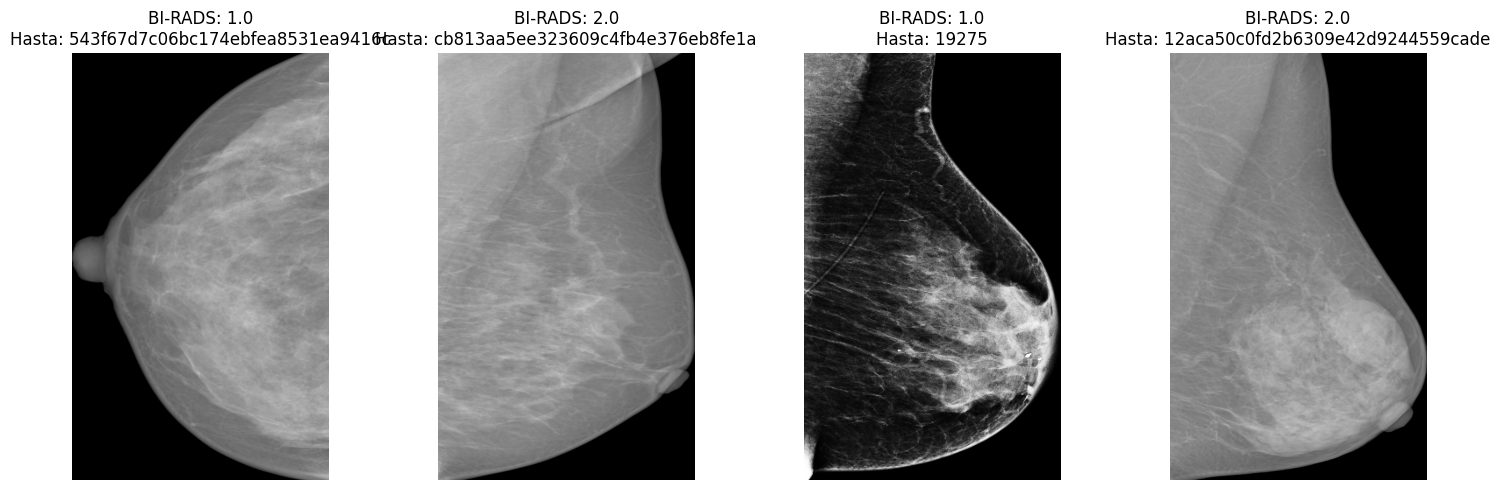


Veri Bölme Mantığı:
Veri seti görüntü bazında rastgele değil, hasta ID'sine (patient_id) göre bölünmüştür. Aynı hastaya ait farklı açılardaki veya farklı memelerdeki (sağ/sol) görüntüler aynı kümeye atanmıştır. Bu yöntem, modelin hastanın anatomik yapısını ezberlemesini ve veri sızıntısını (data leakage) engeller.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'
df_val = pd.read_csv(base_path + 'val_split.csv')

ornekler = df_val.sample(n=4, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, (_, row) in zip(axes, ornekler.iterrows()):
    img_path = row['image_path']
    label = row['birads_label']
    patient = row['patient_id']

    try:
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"BI-RADS: {label}\nHasta: {patient}")
        ax.axis('off')
    except Exception as e:
        ax.set_title("Görüntü Okunamadı")
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\nVeri Bölme Mantığı:")
print("Veri seti görüntü bazında rastgele değil, hasta ID'sine (patient_id) göre bölünmüştür. Aynı hastaya ait farklı açılardaki veya farklı memelerdeki (sağ/sol) görüntüler aynı kümeye atanmıştır. Bu yöntem, modelin hastanın anatomik yapısını ezberlemesini ve veri sızıntısını (data leakage) engeller.")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class ConvNeXTModel(nn.Module):
    def __init__(self, num_classes: int, model_size: str = 'tiny', pretrained: bool = True):
        super(ConvNeXTModel, self).__init__()
        self.model = models.convnext_tiny(weights='IMAGENET1K_V1' if pretrained else None)
        self.model.classifier[2] = nn.Linear(768, num_classes)

    def forward(self, x):
        return self.model(x)

model = ConvNeXTModel(num_classes=4, model_size='tiny')
dummy_input = torch.randn(1, 3, 224, 224)
output = model(dummy_input)

print("Model Çıktı Boyutu:", output.shape)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 180MB/s]


Model Çıktı Boyutu: torch.Size([1, 4])


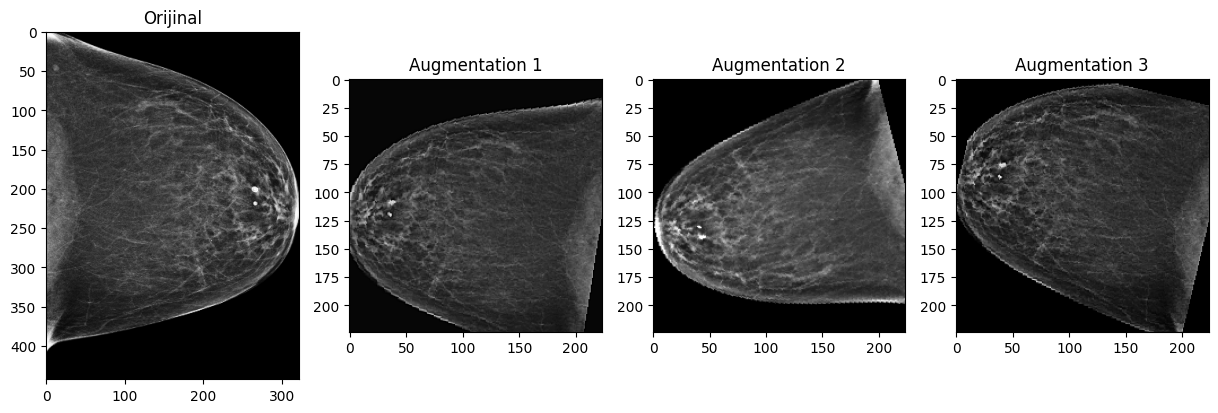

In [ ]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

def get_train_transforms(image_size: int = 224):
    return transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2)
    ])

# img_path değişkenine doğrulama setinden kopyaladığın bir resmin yolunu ver
img_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/RSNA_Cropped/37274_1731534787.png'
image = Image.open(img_path).convert('RGB')

transform = get_train_transforms(224)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Orijinal")

for i in range(1, 4):
    transformed_img = transform(image)
    axes[i].imshow(transformed_img)
    axes[i].set_title(f"Augmentation {i}")

plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd

class ConvNeXTModel(nn.Module):
    def __init__(self, num_classes: int, model_size: str = 'tiny', pretrained: bool = True):
        super(ConvNeXTModel, self).__init__()
        if model_size == 'tiny':
            self.model = models.convnext_tiny(weights='IMAGENET1K_V1' if pretrained else None)
            in_features = 768
        self.model.classifier[2] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

def get_val_transforms(image_size: int = 224):
    return transforms.Compose([
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

df_val = pd.read_csv('/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/val_split.csv')
ornek_satir = df_val.iloc[0]
img_path = ornek_satir['image_path']
gercek_etiket = ornek_satir['birads_label']

image = Image.open(img_path).convert('RGB')
transform = get_val_transforms()
input_tensor = transform(image).unsqueeze(0)

model = ConvNeXTModel(num_classes=4, model_size='tiny', pretrained=True)
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    olasiliklar = torch.softmax(output, dim=1)
    tahmin_edilen_sinif_idx = torch.argmax(olasiliklar, dim=1).item()

print(f"Gerçek Etiket (BI-RADS) ve indeks: {gercek_etiket}, {tahmin_edilen_sinif_idx}")
print(f"Modelin Çıktı Vektörü (Logits): {output.numpy()}")
print(f"Sınıf Olasılıkları: {olasiliklar.numpy()}")
print(f"Tahmin Edilen Sınıf İndeksi: {tahmin_edilen_sinif_idx}")

Gerçek Etiket (BI-RADS) ve indeks: 1.0, 2
Modelin Çıktı Vektörü (Logits): [[ 0.22583553 -0.01527728  0.42321515 -0.37473214]]
Sınıf Olasılıkları: [[0.28149512 0.22118562 0.34291914 0.15440013]]
Tahmin Edilen Sınıf İndeksi: 2


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import pandas as pd
from collections import Counter

class MemeKanseriDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row['image_path']

        etiketler = {1.0: 0, 2.0: 1, 4.0: 2, 5.0: 3}
        label = etiketler[row['birads_label']]

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

def get_train_transforms(image_size=224):
    return transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def get_val_transforms(image_size=224):
    return transforms.Compose([
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'
df_train = pd.read_csv(base_path + 'train_split.csv')
df_val = pd.read_csv(base_path + 'val_split.csv')
df_test = pd.read_csv(base_path + 'test_split.csv')

train_dataset = MemeKanseriDataset(df_train, transform=get_train_transforms())
val_dataset = MemeKanseriDataset(df_val, transform=get_val_transforms())
test_dataset = MemeKanseriDataset(df_test, transform=get_val_transforms())

train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]
class_counts = Counter(train_labels)
num_samples = len(train_labels)

sample_weights = [1.0 / class_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=num_samples, replacement=True)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

for images, labels in train_loader:
    print("Batch Görüntü Boyutu:", images.shape)
    print("Batch Etiket Boyutu:", labels.shape)
    print("Batch İçindeki Sınıf Dağılımı (Dengelenmiş):", Counter(labels.numpy()))
    break

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
from ultralytics import YOLO

# DİKKAT: Buraya kesinlikle kendi eğittiğiniz (örneğin best.pt) modelin yolunu girmelisiniz.
# Eğer yolov8n.pt yazarsa standart model çalışır ve hiçbir şey bulamaz.
model_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/yolov8n.pt'
input_folder = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_PNG_Converted'
output_folder = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped'

os.makedirs(output_folder, exist_ok=True)

model = YOLO(model_path)

for image_name in os.listdir(input_folder):
    if not image_name.endswith('.png'):
        continue

    input_path = os.path.join(input_folder, image_name)
    output_path = os.path.join(output_folder, image_name)

    if os.path.exists(output_path):
        continue

    # Güven eşiğini 0.5'e çektik
    results = model.predict(input_path, save=False, conf=0.5)

    image = cv2.imread(input_path)

    if len(results[0].boxes) > 0:
        box = results[0].boxes.xyxy[0]
        x_min, y_min, x_max, y_max = map(int, box.tolist())

        cropped_image = image[y_min:y_max, x_min:x_max]
        cv2.imwrite(output_path, cropped_image)
        print(f"Kirpildi: {image_name}")
    else:
        cv2.imwrite(output_path, image)
        print(f"Kutu bulunamadi, orijinal eklendi: {image_name}")


image 1/1 /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_PNG_Converted/53586896_6ac23356b912ee9b_MG_L_CC_ANON.png: 640x544 1 vase, 68.1ms
Speed: 3.5ms preprocess, 68.1ms inference, 24.2ms postprocess per image at shape (1, 3, 640, 544)
Kirpildi: 53586896_6ac23356b912ee9b_MG_L_CC_ANON.png

image 1/1 /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_PNG_Converted/53581796_573747ee33ef6e5a_MG_L_CC_ANON.png: 640x512 1 vase, 7.8ms
Speed: 3.0ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 512)
Kirpildi: 53581796_573747ee33ef6e5a_MG_L_CC_ANON.png

image 1/1 /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_PNG_Converted/51048765_3f22cdda8da215e3_MG_R_CC_ANON.png: 640x512 1 vase, 7.2ms
Speed: 3.1ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)
Kirpildi: 51048765_3f22cdda8da215e3_MG_R_CC_ANON.png

image 1/1 /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_PNG_Converted/30011530_349

In [ ]:
import pandas as pd
import glob
import os
from sklearn.model_selection import GroupShuffleSplit

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'

df_inbreast = pd.read_csv(base_path + 'INbreast_cleaned.csv')
df_rsna = pd.read_csv(base_path + 'RSNA_cleaned.csv')
df_vindr = pd.read_csv(base_path + 'VinDr_cleaned.csv')

inbreast_files = glob.glob(base_path + 'INbreast_Cropped/*.png')
inbreast_paths = pd.DataFrame({'image_path': inbreast_files})
inbreast_paths['File Name'] = inbreast_paths['image_path'].apply(lambda x: int(os.path.basename(x).split('_')[0]))
inbreast_paths = inbreast_paths.drop_duplicates(subset=['File Name'])

df_inbreast_merged = pd.merge(df_inbreast, inbreast_paths, on='File Name', how='inner')
df_inbreast_merged = df_inbreast_merged.rename(columns={'birads': 'birads_label', 'Patient ID': 'patient_id'})
df_inbreast_merged['dataset_source'] = 'inbreast'
inbreast_final = df_inbreast_merged[['image_path', 'birads_label', 'dataset_source', 'patient_id']]

rsna_files = glob.glob(base_path + 'RSNA_Cropped/*.png')
rsna_paths = pd.DataFrame({'image_path': rsna_files})
rsna_paths['image_id'] = rsna_paths['image_path'].apply(lambda x: int(os.path.basename(x).split('_')[1].replace('.png', '')))
rsna_paths = rsna_paths.drop_duplicates(subset=['image_id'])

df_rsna_merged = pd.merge(df_rsna, rsna_paths, on='image_id', how='inner')
df_rsna_merged = df_rsna_merged.rename(columns={'birads': 'birads_label'})
df_rsna_merged['dataset_source'] = 'rsna'
rsna_final = df_rsna_merged[['image_path', 'birads_label', 'dataset_source', 'patient_id']]

vindr_files = glob.glob(base_path + 'VinDr_Cropped/*.png')
vindr_paths = pd.DataFrame({'image_path': vindr_files})
vindr_paths['image_id'] = vindr_paths['image_path'].apply(lambda x: os.path.basename(x).split('_')[0].replace('.png', ''))

vindr_paths['is_cropped'] = vindr_paths['image_path'].str.contains('crop')
vindr_paths = vindr_paths.sort_values('is_cropped', ascending=False).drop_duplicates(subset=['image_id'])
vindr_paths = vindr_paths.drop(columns=['is_cropped'])

df_vindr_merged = pd.merge(df_vindr, vindr_paths, on='image_id', how='inner')
df_vindr_merged = df_vindr_merged.rename(columns={'birads': 'birads_label', 'study_id': 'patient_id'})
df_vindr_merged['dataset_source'] = 'vindr'
vindr_final = df_vindr_merged[['image_path', 'birads_label', 'dataset_source', 'patient_id']]

master_df = pd.concat([inbreast_final, rsna_final, vindr_final], ignore_index=True)
master_df.to_csv(base_path + 'master_dataset.csv', index=False)

gss_temp = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss_temp.split(master_df, groups=master_df['patient_id']))

df_train = master_df.iloc[train_idx].copy()
df_temp = master_df.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(df_temp, groups=df_temp['patient_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

df_train.to_csv(base_path + 'train_split.csv', index=False)
df_val.to_csv(base_path + 'val_split.csv', index=False)
df_test.to_csv(base_path + 'test_split.csv', index=False)

print("Master CSV ve Bölme İşlemleri Tamamlandı.\n")
print("Güncel Master Veri Seti Dağılımı:")
print(master_df['dataset_source'].value_counts())
print("\nGüncel Train Seti BI-RADS Dağılımı:")
print(df_train['birads_label'].value_counts(dropna=False).sort_index())
print(f"\nVeri Sayıları - Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Master CSV ve Bölme İşlemleri Tamamlandı.

Güncel Master Veri Seti Dağılımı:
dataset_source
vindr       19070
inbreast      379
Name: count, dtype: int64

Güncel Train Seti BI-RADS Dağılımı:
birads_label
1.0    10779
2.0     3952
4.0      649
5.0      235
Name: count, dtype: int64

Veri Sayıları - Train: 15615, Val: 1920, Test: 1914


In [ ]:
import pandas as pd

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'

csv_dosyalari = {
    'Train Seti': 'train_split.csv',
    'Validation Seti': 'val_split.csv',
    'Test Seti': 'test_split.csv'
}

for set_adi, dosya_adi in csv_dosyalari.items():
    df = pd.read_csv(base_path + dosya_adi)

    ornekler = df.sample(n=2, random_state=42)

    print(f"--- {set_adi} ({dosya_adi}) ---")
    for index, row in ornekler.iterrows():
        print(f"Tam Yol: {row['image_path']}")
        print(f"Kaynak: {row['dataset_source']} | BI-RADS: {row['birads_label']} | Hasta ID: {row['patient_id']}")
        print("-" * 60)
    print("\n")

df_master = pd.read_csv(base_path + 'master_dataset.csv')
inbreast_ornekler = df_master[df_master['dataset_source'] == 'inbreast'].sample(n=3, random_state=42)

print("--- SADECE INBREAST KONTROLÜ (master_dataset.csv) ---")
for index, row in inbreast_ornekler.iterrows():
    print(f"Tam Yol: {row['image_path']}")
    print(f"Kaynak: {row['dataset_source']} | BI-RADS: {row['birads_label']} | Hasta ID: {row['patient_id']}")
    print("-" * 60)

--- Train Seti (train_split.csv) ---
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/VinDr_Cropped/88e68a69fc30be13a86fcd1f18a4d5e1_crop0.png
Kaynak: vindr | BI-RADS: 1.0 | Hasta ID: 33a3c7b1ea1b9b72d28bd57043d7a215
------------------------------------------------------------
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/VinDr_Cropped/a763d5dfd875b5575918bd8e97c651f6.png
Kaynak: vindr | BI-RADS: 4.0 | Hasta ID: e315902ce49832b4714312a985617af2
------------------------------------------------------------


--- Validation Seti (val_split.csv) ---
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/VinDr_Cropped/8b888a1a6c6610e3b3104e2b95c32f71.png
Kaynak: vindr | BI-RADS: 1.0 | Hasta ID: 04e48ccb2c1da42c6e51ec0e03d12863
------------------------------------------------------------
Tam Yol: /content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/VinDr_Cropped/0d07aec4f7e9fd2d7c70e0cf003bf35a.png
Kaynak: vindr | BI-RADS: 1.0 | Hasta ID: ce33779191cd4945794b2591b

In [ ]:
import pandas as pd
import os

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'
master_df = pd.read_csv(base_path + 'master_dataset.csv')

inbreast_df = master_df[master_df['dataset_source'] == 'inbreast']

print("INbreast için kullanılan klasör yolları:")
klasorler = inbreast_df['image_path'].apply(os.path.dirname).unique()
for klasor in klasorler:
    print(klasor)

print("\nÖrnek 5 dosya yolu:")
for yol in inbreast_df['image_path'].head(5):
    print(yol)

INbreast için kullanılan klasör yolları:
/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped

Örnek 5 dosya yolu:
/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22678622_61b13c59bcba149e_MG_R_CC_ANON.png
/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22678670_61b13c59bcba149e_MG_R_ML_ANON.png
/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22614074_6bd24a0a42c19ce1_MG_R_CC_ANON.png
/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22614097_6bd24a0a42c19ce1_MG_L_CC_ANON.png
/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/INbreast_Cropped/22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.png


In [ ]:
import pandas as pd
import glob
import os
from sklearn.model_selection import GroupShuffleSplit

base_path = '/content/drive/MyDrive/Meme_Kanseri_Proje_Verileri/'

df_inbreast = pd.read_csv(base_path + 'INbreast_cleaned.csv')
df_rsna = pd.read_csv(base_path + 'RSNA_cleaned.csv')
df_vindr = pd.read_csv(base_path + 'VinDr_cleaned.csv')

inbreast_files = glob.glob(base_path + 'INbreast_Cropped/*.png')
inbreast_paths = pd.DataFrame({'image_path': inbreast_files})
inbreast_paths['File Name'] = inbreast_paths['image_path'].apply(lambda x: int(os.path.basename(x).split('_')[0]))
inbreast_paths = inbreast_paths.drop_duplicates(subset=['File Name'])

df_inbreast_merged = pd.merge(df_inbreast, inbreast_paths, on='File Name', how='inner')
df_inbreast_merged = df_inbreast_merged.rename(columns={'birads': 'birads_label', 'Patient ID': 'patient_id'})
df_inbreast_merged['dataset_source'] = 'inbreast'
inbreast_final = df_inbreast_merged[['image_path', 'birads_label', 'dataset_source', 'patient_id']]

rsna_files = glob.glob(base_path + 'RSNA_Cropped/*.png')
rsna_paths = pd.DataFrame({'image_path': rsna_files})
rsna_paths['image_id'] = rsna_paths['image_path'].apply(lambda x: int(os.path.basename(x).split('_')[1].replace('.png', '')))
rsna_paths = rsna_paths.drop_duplicates(subset=['image_id'])

df_rsna_merged = pd.merge(df_rsna, rsna_paths, on='image_id', how='inner')
df_rsna_merged = df_rsna_merged.rename(columns={'birads': 'birads_label'})
df_rsna_merged['dataset_source'] = 'rsna'
rsna_final = df_rsna_merged[['image_path', 'birads_label', 'dataset_source', 'patient_id']]

vindr_files = glob.glob(base_path + 'VinDr_Cropped/*.png')
vindr_paths = pd.DataFrame({'image_path': vindr_files})
vindr_paths['image_id'] = vindr_paths['image_path'].apply(lambda x: os.path.basename(x).split('_')[0].replace('.png', ''))

vindr_paths['is_cropped'] = vindr_paths['image_path'].str.contains('crop')
vindr_paths = vindr_paths.sort_values('is_cropped', ascending=False).drop_duplicates(subset=['image_id'])
vindr_paths = vindr_paths.drop(columns=['is_cropped'])

df_vindr_merged = pd.merge(df_vindr, vindr_paths, on='image_id', how='inner')
df_vindr_merged = df_vindr_merged.rename(columns={'birads': 'birads_label', 'study_id': 'patient_id'})
df_vindr_merged['dataset_source'] = 'vindr'
vindr_final = df_vindr_merged[['image_path', 'birads_label', 'dataset_source', 'patient_id']]

master_df = pd.concat([inbreast_final, rsna_final, vindr_final], ignore_index=True)
master_df.to_csv(base_path + 'master_dataset.csv', index=False)

gss_temp = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss_temp.split(master_df, groups=master_df['patient_id']))

df_train = master_df.iloc[train_idx].copy()
df_temp = master_df.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(df_temp, groups=df_temp['patient_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

df_train.to_csv(base_path + 'train_split.csv', index=False)
df_val.to_csv(base_path + 'val_split.csv', index=False)
df_test.to_csv(base_path + 'test_split.csv', index=False)

print("Master CSV ve Bölme İşlemleri Tamamlandı.\n")
print("Güncel Master Veri Seti Dağılımı:")
print(master_df['dataset_source'].value_counts())
print("\nGüncel Train Seti BI-RADS Dağılımı:")
print(df_train['birads_label'].value_counts(dropna=False).sort_index())
print(f"\nVeri Sayıları - Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

TypeError: '<' not supported between instances of 'int' and 'str'